In [ ]:
# Product Authentication using Feature-Based Computer Vision

In [1]:
!pip install opencv-python

In [2]:
from google.colab import files
uploaded = files.upload()

Saving nb.jpg to nb.jpg
Saving angle.jpg to angle.jpg
Saving back.jpg to back.jpg
Saving left.jpg to left.jpg
Saving right.jpg to right.jpg
Saving top.jpg to top.jpg


In [20]:
def compare_images(img1_path, img2_path):
    import cv2

    img1 = cv2.imread(img1_path, 0)
    img2 = cv2.imread(img2_path, 0)

    orb = cv2.ORB_create()

    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    good_matches = [m for m in matches if m.distance < 50]

    similarity = len(good_matches) / max(len(kp1), len(kp2))

    return similarity

In [21]:
print("Left vs Angle:", compare_images("left.jpg", "angle.jpg"))
print("Left vs Top:", compare_images("left.jpg", "top.jpg"))
print("Left vs Back:", compare_images("left.jpg", "back.jpg"))
print("Left vs Right:", compare_images("left.jpg", "right.jpg"))
print("Left vs NB (Different):", compare_images("left.jpg", "nb.jpg"))

Left vs Angle: 0.1
Left vs Top: 0.008
Left vs Back: 0.038
Left vs Right: 0.128
Left vs NB (Different): 0.0


In [22]:
import matplotlib.pyplot as plt

def show_matches(img1_path, img2_path):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    orb = cv2.ORB_create()
    kp1, des1 = orb.detectAndCompute(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = orb.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    good_matches = [m for m in matches if m.distance < 50]

    img_match = cv2.drawMatches(img1, kp1, img2, kp2, good_matches[:20], None)

    plt.figure(figsize=(10,5))
    plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
    plt.axis('off')

Feature Matching: Same Shoe (Different Angles)
Feature Matching: Same Shoe (Left vs Top view)
Feature Matching: Same Shoe (Left vs Back)
Feature Matching: Same Shoe (Side vs Side)
Feature Matching: Different Shoes


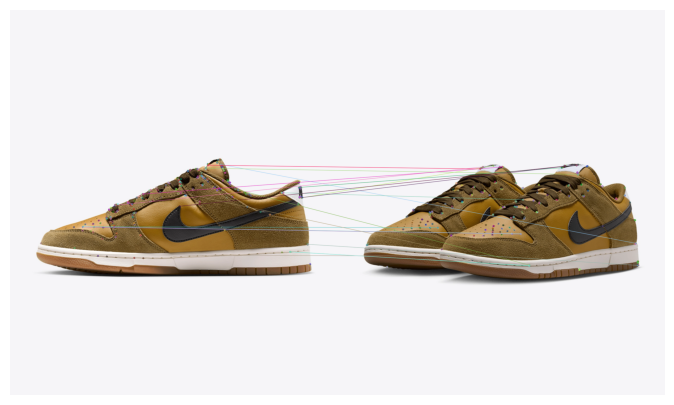

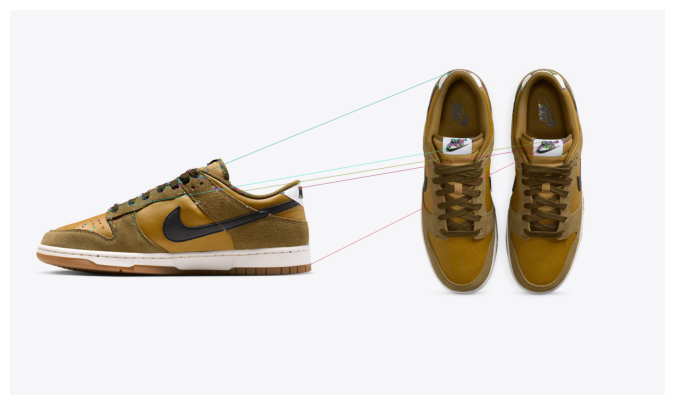

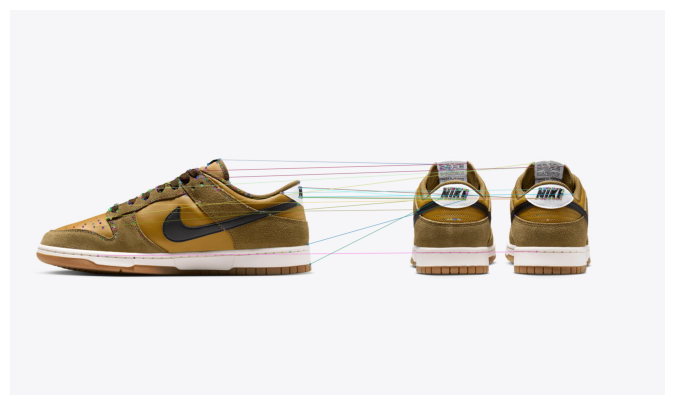

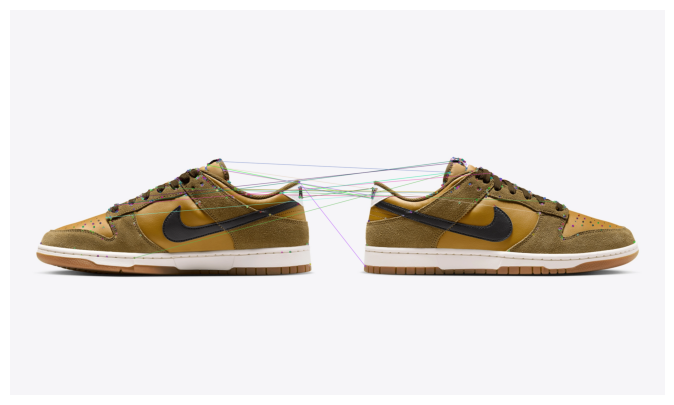

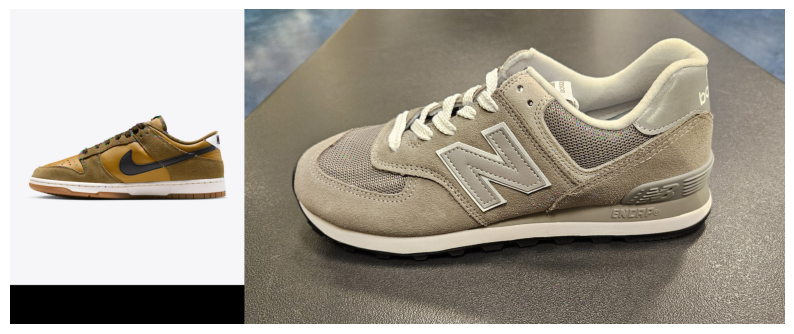

In [23]:
print("Feature Matching: Same Shoe (Different Angles)")
show_matches("left.jpg", "angle.jpg")

print("Feature Matching: Same Shoe (Left vs Top view)")
show_matches("left.jpg", "top.jpg")

print("Feature Matching: Same Shoe (Left vs Back)")
show_matches("left.jpg", "back.jpg")

print("Feature Matching: Same Shoe (Side vs Side)")
show_matches("left.jpg", "right.jpg")


print("Feature Matching: Different Shoes")
show_matches("left.jpg", "nb.jpg")

## 🔍 Final Observations

- Same product images show **strong feature matching**
- Similarity **decreases with viewpoint change**
- Different products show **minimal to no matching**

---

## ✅ Conclusion

Feature-based matching using ORB can effectively distinguish products based on visual patterns, while remaining lightweight and interpretable.